# Application to one case

This notebook walks through a complete attribution workflow for a single Tropical Cyclone (TC) case using the `tc_track_analogues` package.


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from glob import glob
import pickle as pkl
from tqdm import tqdm
import os
import huracanpy

from scipy.stats import ttest_ind, cramervonmises_2samp

import tc_track_analogues as tca

## 1. Define the target

In [2]:
NAME, SEASON, BASIN = "MELISSA", 2025, "NA"
LANDFALL_TIME = "2025-10-28T18:00:00"
TIME_WINDOW = 24 # in hours

/Users/sbourdin/miniforge3/envs/tc-track-analogues/lib/python3.14/site-packages/huracanpy/_data/_csv.py:65: DtypeWarning: Columns (61,66,77) have mixed types. Specify dtype option on import or set low_memory=False.
  tracks = load_function(filename, **kwargs)


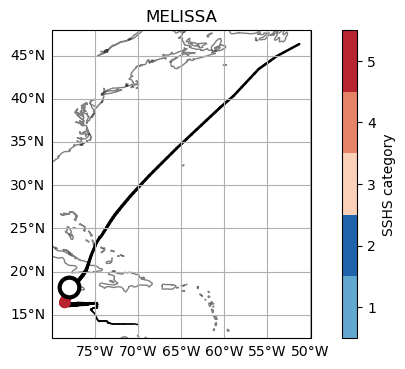

In [3]:
# Identify target case's track in IBTrACS
target = tca.load_target_track_hourly(NAME, SEASON, BASIN)
landfall = target.sel(time = LANDFALL_TIME)
target_window_before_landfall = tca.extract_target_window_before_landfall(
                                        target, LANDFALL_TIME, TIME_WINDOW
                                        )
# Visualise the target
tca.plot_target_case(target, target_window_before_landfall, landfall, NAME)

## 2. Define the catalogues

In [9]:
catalogues = {
    "IBTrACS":tca.load_ibtracs_catalogue(BASIN, update = False),
    "CHAZ":tca.load_CHAZ_catalogue(),
    "MIT":tca.load_MIT_catalogue(),
    "SEAS520C":tca.load_SEAS520C_catalogue(),
}

/Users/sbourdin/miniforge3/envs/tc-track-analogues/lib/python3.14/site-packages/huracanpy/_data/_csv.py:65: DtypeWarning: Columns (21,139,159) have mixed types. Specify dtype option on import or set low_memory=False.
  tracks = load_function(filename, **kwargs)


In [ ]:
## Parameters associated to the catalogues
parameters = pd.DataFrame({
    "index":catalogues.keys(),
    "intensity_cols": 
        [['wind', 'pres'], 
         ['wind'], 
         ['wind'],
         ['wind', 'pres']],
    "dates":
        [[1950, 1984, 1985, 2019], 
         [1950, 1984, 1985, 2019], 
         [1950, 1984, 1985, 2019], 
         [1901, 1955, 1956, 2010], 
        ],
    "LF_DIST":
        [1000, 300, 300, 300],
    "d_max":
        [3.,1., 1., 1.5]
}).set_index("index")

FileNotFoundError: [Errno 2] No such file or directory: '../ClimateCentral_TC_Attribution_intercomparison/data/ib_1h.pkl'